In [1]:
from IH_main import *
from IH_data_analysis import Insert_Halo_Data_Analysis
import numpy as np
import matplotlib.pyplot as plt
import time

import copy
from scipy.integrate import cumulative_trapezoid

In [2]:
# Running Insert Halo for SIDM:

start_time = time.time()
IH = Insert_Halo()
base_run_SIDM = IH.run_insert_halo(idle_run = False, spatial = "einasto", DM_type = "SIDM", sigma_0 = 100, vel_scale = 24.33, zsource = 2.0, msub_min = 6, 
                   cone_angle_arcsec = 10, geometry_shape = "DOUBLE_CONE", sh_tt_th = 1.1)
end_time = time.time()
print(f"Run time: {end_time - start_time:.2f} seconds")

Calculating subhalo properties: 100%|█████████| 128/128 [00:55<00:00,  2.31it/s]


Run time: 111.68 seconds


In [3]:

SIDM_halos = base_run_SIDM.PH.SIDM_dist.halos
mass_integral = base_run_SIDM.mass_int_3d

In [4]:
# Checking SIDM masses:
m200_SIDM = []
m200_int_SIDM = []
t_over_tc = []

halo_is = []
halo_isnot = []
collapsed_props = []


for i, halo in enumerate(SIDM_halos):
    m200_SIDM.append(halo.mass)
    SIDM_args = halo.profile_args
    if halo.is_subhalo:
        if halo.has_collapsed:
            r_array = np.logspace(-3, 3, 1000)
            collapsed_props.append(SIDM_args)
        else:
            r_array = np.logspace(-3, 3, 1000)
        halo_is.append(i)
    elif not halo.is_subhalo:
        if halo.has_collapsed:
            r_array = np.logspace(-3, np.log10(halo.r200), 1000)
            collapsed_props.append(SIDM_args)
        else:
            r_array = np.logspace(-3, np.log10(halo.r200), 1000)
        halo_isnot.append(i)
    m200_int_SIDM.append(mass_integral(r_array, halo.profile_args))
    t_over_tc.append(halo.t_over_tc)

m200_SIDM = np.array(m200_SIDM)
m200_int_SIDM = np.array(m200_int_SIDM)
t_over_tc = np.array(t_over_tc)


Subhalo relative difference: minimal: 4.51e-14, maximum: 9.21e-01
Field halo relative difference: minimal: 2.00e-07, maximum: 5.74e-01


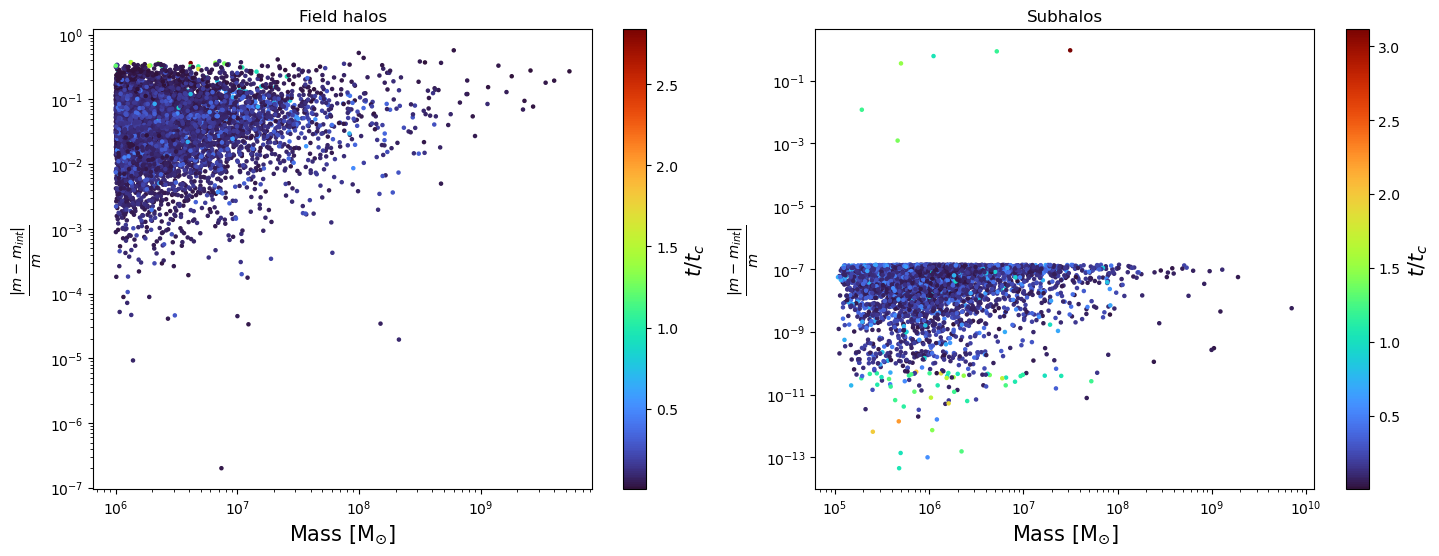

In [5]:

mass_rel_sub = np.abs((m200_SIDM[halo_is] - m200_int_SIDM[halo_is])) / m200_SIDM[halo_is]
mass_rel_field = np.abs((m200_SIDM[halo_isnot] - m200_int_SIDM[halo_isnot])) / m200_SIDM[halo_isnot]


fig, ax = plt.subplots(1, 2)
fig.set_size_inches(15, 6)
fig.tight_layout(pad = 4)
color0 = ax[0].scatter(m200_SIDM[halo_isnot], mass_rel_field, s = 5, cmap = "turbo", c = t_over_tc[halo_isnot])
color1 = ax[1].scatter(m200_SIDM[halo_is], mass_rel_sub, s = 5, cmap = "turbo", c = t_over_tc[halo_is])
cbar0 = fig.colorbar(color0, ax = ax[0])
cbar0.set_label(r"$t/t_c$", fontsize = 15)
cbar1 = fig.colorbar(color1, ax = ax[1])
cbar1.set_label(r"$t/t_c$", fontsize = 15)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[0].set_title("Field halos")
ax[1].set_title("Subhalos")

ax[0].set_xlabel(r"Mass [M$_{\odot}$]", fontsize = 15)
ax[0].set_ylabel(r"$\frac{\vert m - m_{int}\vert}{m}$", fontsize = 15)

ax[1].set_xlabel(r"Mass [M$_{\odot}$]", fontsize = 15)
ax[1].set_ylabel(r"$\frac{\vert m - m_{int}\vert}{m}$", fontsize = 15)

print(f"Subhalo relative difference: minimal: {np.min(mass_rel_sub):.2e}, maximum: {np.max(mass_rel_sub):.2e}")
print(f"Field halo relative difference: minimal: {np.min(mass_rel_field):.2e}, maximum: {np.max(mass_rel_field):.2e}")


save_fig = False
if save_fig:
    plt.savefig(f"/home/stefan/Documents/uva/Thesis/Images/Insert_halo/Field_and_Subhalo_mass_integral.png", bbox_inches = "tight")
plt.show() 

In [6]:
# Isolating the subhalos with relative mass errors larger than 1e-3:


mass_rel_sub = np.abs((m200_SIDM[halo_is] - m200_int_SIDM[halo_is])) / m200_SIDM[halo_is]
SIDM_halos = np.array(SIDM_halos)

rel_sub_limit = 1e-3
limit_cond = mass_rel_sub > rel_sub_limit


subhalos_problem = []

for halo, truth in zip(SIDM_halos[halo_is], limit_cond):
    if truth:
        subhalos_problem.append(halo)
subhalos_problem = np.array(subhalos_problem)

props = []
t_tc = []
mass_c = []

for halo in subhalos_problem:
    props.append(halo.profile_args)
    t_tc.append(halo.t_over_tc)
    mass_c.append(halo.mass)

props = np.array(props)
t_tc = np.array(t_tc)
mass_c = np.array(mass_c)

#mass_integral


sh = base_run_SIDM.sh
get_rhos = sh.get_rhos
get_rs = sh.get_rs
get_rc = sh.get_rc
num_find_rt = base_run_SIDM.num_new_truncation

r_array = np.logspace(-3, 3, 1000)

rel_mass_arrays = []
tau_arrays = []
rhos_arrays = []
rt_arrays = []

rs_arrays = []
rc_arrays = []

# Here I use the basic approach to see how the properties of the halos would have evolved over time using this method. This is not how Sashimi computed the subhalo properties,
# but I just wanted to see what would happen if I changed the subhalo properties a bit from being collapsed:

for i, halo in enumerate(subhalos_problem):
    rel_mass_arrays.append([])
    tau_arrays.append([])
    rhos_arrays.append([])
    rt_arrays.append([])

    rs_arrays.append([])
    rc_arrays.append([])
    
    if halo.t_over_tc <= 1.1:
        tau_array = np.linspace(0, halo.t_over_tc, 100)
    else:
        tau_array = np.linspace(0, base_run_SIDM.IHB.sh_tt_th, 100)

    tau_arrays[i] = tau_array

    rhos_e_array = get_rhos(1, tau_array)
    rs_e_array = get_rs(1, tau_array)
    rc_e_array = get_rc(1, tau_array)

    props_at_tau_max = halo.profile_args
    
    rhos_0 = props_at_tau_max["rhos"] / rhos_e_array[-1]
    rs_0 = props_at_tau_max["rs"] / rs_e_array[-1]

    rhos_arrays[i] = rhos_0 * rhos_e_array
    rs_arrays[i] = rs_0 * rs_e_array
    rc_arrays[i] = rs_0 * rc_e_array

    for rhos_e, rs_e, rc_e in zip(rhos_e_array, rs_e_array, rc_e_array):
        props = {"profile": "TNFWC_SH_tau", "rhos": rhos_e * rhos_0, "rs": rs_e * rs_0, "rc": rc_e * rs_0}
        props["rt"] = num_find_rt(halo.mass, 3, props, Nr = 1000, Nt = 100, log_rmin = -3, rt_logmin = -3, rt_logmax = 2)

        mass_int = mass_integral(r_array, props)
        rel_mass_arrays[i].append(np.abs(halo.mass - mass_int) / halo.mass)
        rt_arrays[i].append(props["rt"])
        

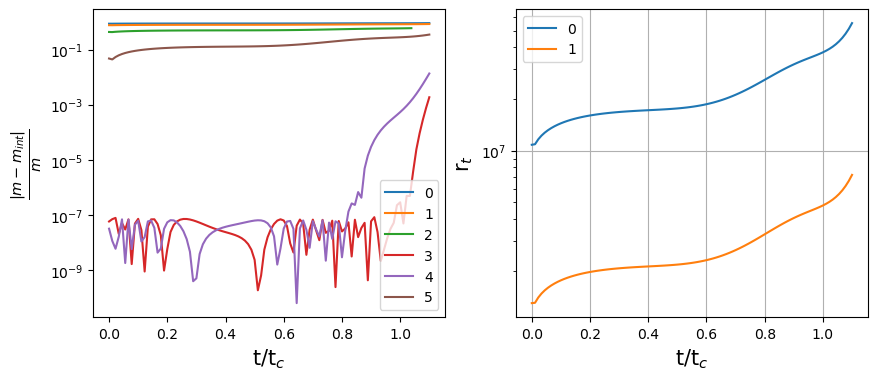

In [7]:
# Plotting the relative mass difference as function of time for the problematic halos

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 4)
#fig.tight_layout(pad = 4)



index = 0
for rel_mass, tau_array in zip(rel_mass_arrays, tau_arrays):
    #if index == 14 or index == 6 or index == 1 or index == 0:
    ax[0].plot(tau_array, rel_mass, label = f"{index}")
    index += 1

index = 0
for rt_array, tau_array in zip(rt_arrays, tau_arrays):
    if index == 14 or index == 6 or index == 1 or index == 0:
        ax[1].plot(tau_array, rt_array, label = f"{index}")
    index += 1

ax[0].set_yscale("log")
ax[0].set_xlabel(r"t/t$_c$", fontsize = 15)
ax[0].set_ylabel(r"$\frac{\vert m - m_{int}\vert}{m}$", fontsize = 15)
ax[0].legend()

ax[1].set_yscale("log")
ax[1].set_xlabel(r"t/t$_c$", fontsize = 15)
ax[1].set_ylabel(r"r$_t$", fontsize = 15)
ax[1].legend()
ax[1].grid()



$\textbf{Doing some in depth testing for one particular halo to see why the integration fails 'over time'}$

0.6039098724904133


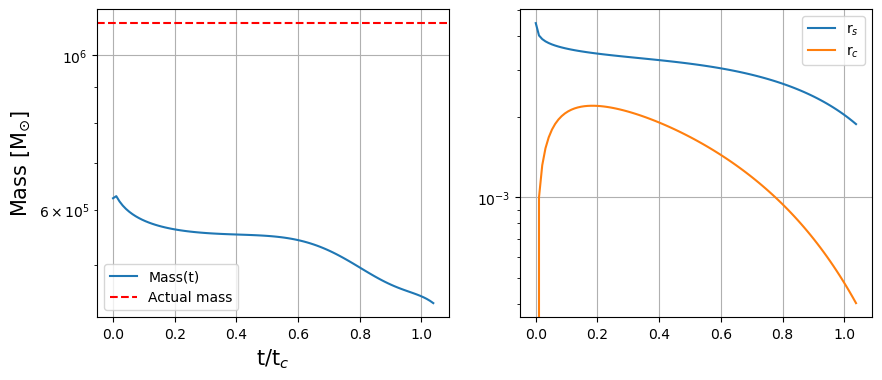

In [9]:
halo_index = 2

print(rel_mass_arrays[halo_index][-1])

subhalo = subhalos_problem[halo_index]

rel_mass = np.array(rel_mass_arrays[halo_index])
tau_array = tau_arrays[halo_index]

#mass_int = (rel_mass * subhalo.mass) - subhalo.mass
rhos_array = rhos_arrays[halo_index]
rt_array = rt_arrays[halo_index]

rs_array = rs_arrays[halo_index]
rc_array = rc_arrays[halo_index]

r_array = np.logspace(-3, 3, 1000)

mass_int = []


for rhos, rs, rc, rt in zip(rhos_array, rs_array, rc_array, rt_array):
    props = {"profile": "TNFWC_SH_tau", "rhos": rhos, "rs": rs, "rc": rc, "rt": rt}
    #props["rt"] = num_find_rt(halo.mass, 3, props, Nr = 1000, Nt = 100, log_rmin = -3, rt_logmin = -3, rt_logmax = 2)
    mass_int_ = mass_integral(r_array, props)
    mass_int.append(mass_int_)
    #rt_arrays[i].append(props["rt"])

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 4)


ax[0].plot(tau_array, mass_int, label = "Mass(t)")
#plt.yscale("log")

xmin, xmax = ax[0].set_xlim()

ax[0].plot([xmin, xmax], [subhalo.mass, subhalo.mass], linestyle = "--", color = "red", label = "Actual mass")
ax[0].set_xlim(xmin, xmax)

ax[0].set_yscale("log")
ax[0].set_xlabel(r"t/t$_c$", fontsize = 15)
ax[0].set_ylabel(r"Mass [M$_{\odot}$]", fontsize = 15)
ax[0].legend()
ax[0].grid()

ax[1].plot(tau_array, rs_array, label = r"r$_s$")
ax[1].plot(tau_array, rc_array, label = r"r$_c$")
ax[1].grid()
ax[1].set_yscale("log")
ax[1].legend()

356574.7077737203
1112224.0928472113
{'profile': 'TNFWC_SH_tau', 'rhos': 436234277895.4613, 'rs': 0.001879454224330264, 'rc': 0.00040335154189891434, 'rt': 100}


Text(0, 0.5, 'Mass [M$_{\\odot}$]')

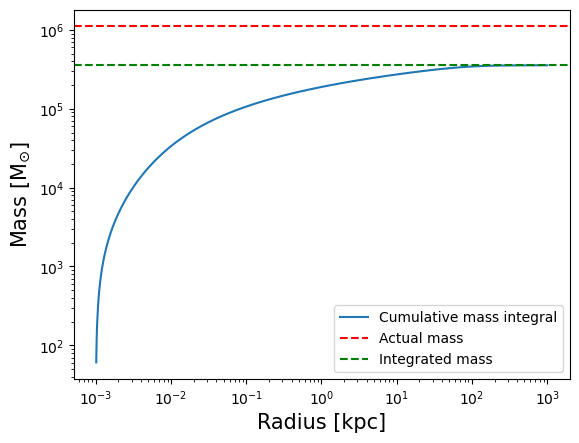

In [52]:
# Checking the cumulative mass for one of the problematic collapsed subhalos.
# The plot clearly shows that the integrated does not reach the actual mass for some reason


props = subhalos_problem[halo_index].profile_args
props_c = copy.deepcopy(props)

props_c["rt"] = 100
props_c["rhos"] = props["rhos"]
r_array = np.logspace(-3, 3, 1000)
density = base_run_SIDM.TNFWC_SH_tau(r_array, props_c)
mass = mass_int_3d(r_array, props_c)

print(mass)
print(subhalos_problem[halo_index].mass)
print(props_c)


m_cumulative = 4 * np.pi * cumulative_trapezoid(r_array**2 * density, r_array)


plt.plot(r_array[1:], m_cumulative, label = "Cumulative mass integral")
plt.xscale("log")
plt.yscale("log")

xmin, xmax = plt.xlim()

plt.plot([xmin, xmax], [subhalo.mass, subhalo.mass], linestyle = "--", color = "red", label = "Actual mass")
plt.plot([xmin, xmax], [mass, mass], linestyle = "--", color = "green", label = "Integrated mass")
plt.xlim(xmin, xmax)
plt.legend()

plt.xlabel("Radius [kpc]", fontsize = 15)
plt.ylabel(r"Mass [M$_{\odot}$]", fontsize = 15)
